# Data Cleaning and Visualization 
In this project I will work with a intentionally "dirty" cafe sales dataset containing 10,000 transactions. The dataset simulates common data quality issues such as missing values, inconsistent formats, invalid entries (e.g., "ERROR", "UNKNOWN"), and logical mismatches between related columns.

The goal of this project is to demonstrate practical data cleaning, validation, and exploratory data analysis (EDA) skills by transforming messy transactional data into a reliable dataset that can support business insights.

Data Source: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training (Kaggle)

In [294]:
# Package imports
import numpy as np

import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams['figure.figsize'] = (12, 9)
plt.rcParams['font.size'] = 12

First let's import the file and see that is inside, so we will start by looking at all the current columns in our initial data.

In [295]:
initial_data = pd.read_csv('dirty_cafe_sales.csv')
initial_data.columns.values

array(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Location', 'Transaction Date'],
      dtype=object)

In [296]:
initial_data.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


As mentioned in Kaggle, the dataset contians missing values (row 8 item), invalid values (row 2 Total Spent), price inconsistency (not shown but will deal later). 

Let's better understand the dataset.

In [297]:
initial_data.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [298]:
initial_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


Some conclusions I arrived are:
1. Several columns contain missing values (Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, and Transaction Date all have fewer than 10,000 non-null values.)
2. All columns are stores as string type, even when columns like Quantity, Price Per Unit, and Total Spent should be numerical.
3. Transaction ID is clean and complete.
4. Transaction Date is not a datetime type.

Let's first merge the two tables together.

## Data Cleaning

### Fix Data Types
Currently, numeric columns are stored as text. We convert them so we can perform calculations later.

In [299]:
data = initial_data.copy()
num_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

data[num_cols].dtypes

Quantity          float64
Price Per Unit    float64
Total Spent       float64
dtype: object

### Missing and Empty values
Let's now deal with the missing and empty values. Before filling in, let us convert all the placeholder strings like "ERROR" and "UNKNOWN" in to NaN to pandas can recognize them.

In [300]:
invalid_markers = ['ERROR', 'UNKNOWN', 'None', '']
data = data.replace(invalid_markers, np.nan)
data.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

Kaggle presents a menu items list with the items and their corresponding prices. So I will create a dictionary of prices and use this logic to fill in gaps.

For the missing Price Per Unit, Total Spent, Quantity, we can fill in using the `menu_price` table. 

We know that `Total Spent = Quantiy x Price Per Unit`, so is one value is missing, we can compute it from the other two.

In [301]:
item_prices = {
    'Coffee': 2.0, 'Tea': 1.5, 'Sandwich': 4.0, 'Salad': 5.0, 
    'Cake': 3.0, 'Cookie': 1.0, 'Smoothie': 4.0, 'Juice': 3.0
}

In [302]:
data['Price Per Unit'] = data['Price Per Unit'].fillna(data['Item'].map(item_prices))

data['Total Spent'] = data['Total Spent'].fillna(data['Quantity'] * data['Price Per Unit'])

data['Quantity'] = data['Quantity'].fillna(data['Total Spent'] / data['Price Per Unit'])

Now let's check how many numeric values are still missing.

In [303]:
data[['Item', 'Quantity', 'Price Per Unit', 'Total Spent']].isna().sum()

Item              969
Quantity           23
Price Per Unit     54
Total Spent        23
dtype: int64

One final small observation is that when Payment Method is 'Cash', then the location must be in store. However, for the other missing values we can't infer anything.

In [304]:
mask = (data['Payment Method'] == 'Cash') & (data['Location'].isna())
data.loc[mask, 'Location'] = 'In-store'

For remaining missing numeric values (Quantity, Price Per Unit, Total Spent), I chose not to use statistical imputation such as the median, since doing so would fabricate transactions and distort sales metrics. Instead, these rows are retained with missing values and excluded only in analyses that require complete numeric data.

For categorical fields such as Item, Payment Method, and Location, missing values were labeled as "Unknown" to preserve transaction counts while avoiding incorrect assumptions about the category.

In [305]:
cols = ['Item', 'Payment Method', 'Location']
for c in cols:
    data[c] = data[c].fillna("Unknown")

### Standarize Transaction Date
Transaction Date is currently stored as Obejct, for later visualization, I believe changing to datetime type would be simpler to analyze.

In [306]:
data['Transaction Date'] = pd.to_datetime(data['Transaction Date'], errors="coerce")

And we will add more columns on time feature ("Month" and "Day of week")

In [307]:
data['Month'] = data['Transaction Date'].dt.month
data['Day of Week'] = data['Transaction Date'].dt.day_name()

I will also create a Revenue column that can help in many plots.

In [308]:
data['Revenue'] = data['Quantity'] * data['Price Per Unit']
data.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Day of Week,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0,Friday,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5.0,Tuesday,12.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7.0,Wednesday,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,4.0,Thursday,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0,Sunday,4.0


## EDA and Visualizations

Now that the dateset is cleaned, we can start exploring and look into the questions for analysis. 

I'll begin by identifying which products are the financial engines of the café. By comparing Total Revenue against Total Quantity, I can distinguish between `High-Volume` items (like Coffee) that drive daily foot traffic and `High-Value` items (like Salads)

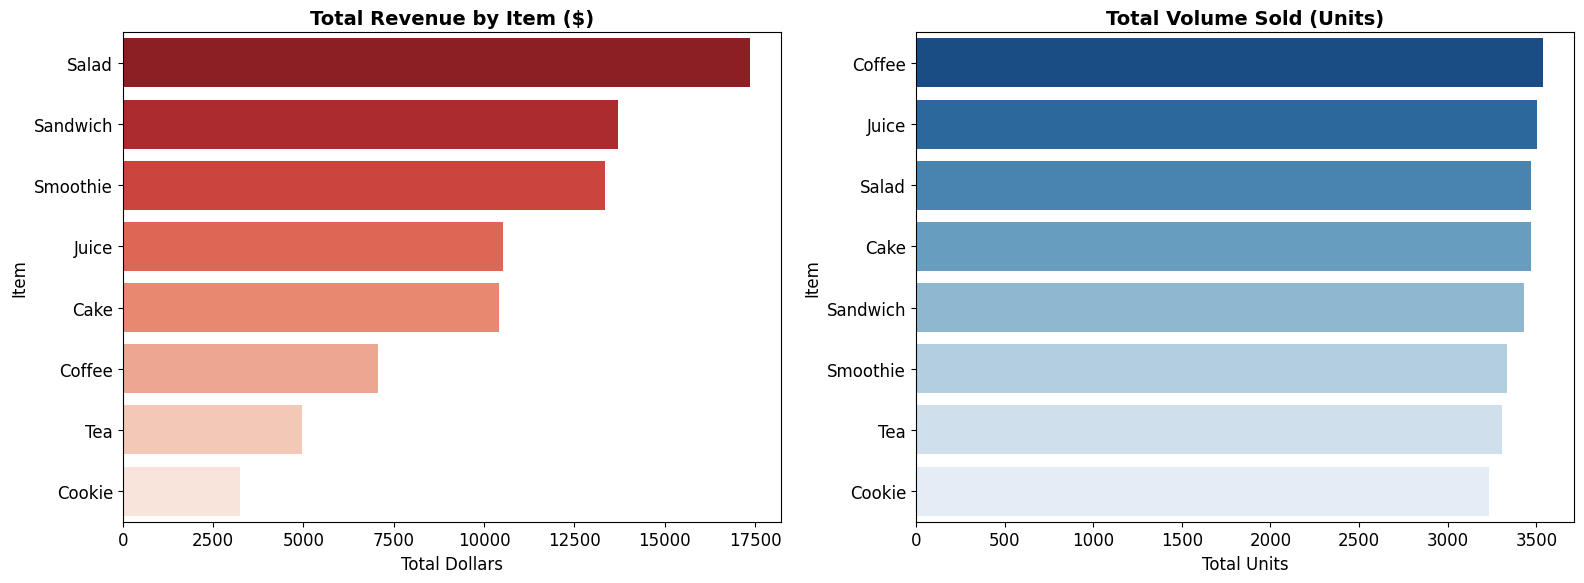

In [309]:
item_stats = data[data['Item'] != 'Unknown'].groupby('Item').agg(
    Total_Revenue=('Total Spent', 'sum'),
    Total_Quantity=('Quantity', 'sum')
).sort_values(by='Total_Revenue', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#Chart 1
sns.barplot(x=item_stats['Total_Revenue'], y=item_stats.index, ax=ax1, palette='Reds_r')
ax1.set_title('Total Revenue by Item ($)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Total Dollars')

# Chart 2
item_stats_qty = item_stats.sort_values(by='Total_Quantity', ascending=False)
sns.barplot(x=item_stats_qty['Total_Quantity'], y=item_stats_qty.index, ax=ax2, palette='Blues_r')
ax2.set_title('Total Volume Sold (Units)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Units')

plt.tight_layout()
plt.show()

Now I look for Seasonal Spikes. By aggregating revenue by month, I can see if the café experiences 'peaks' during specific times of the year (like holiday seasons or summer). This can help in long-term inventory planning and understanding when the business is most profitable. I also compared profits per weekday to see if there are specific dyas with high sales.

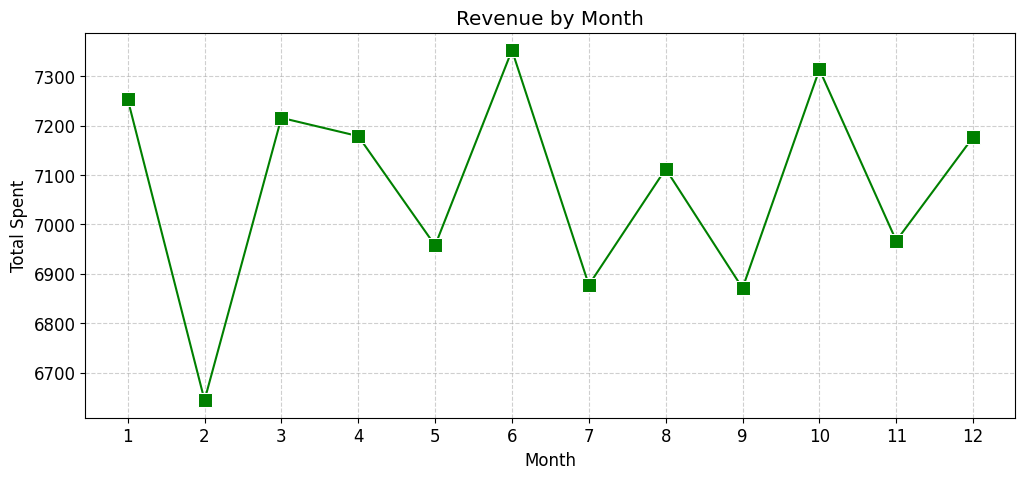

In [310]:
monthly_sales = data.groupby('Month')['Total Spent'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Total Spent', marker='s', color='green', markersize=10)
plt.xticks(range(1, 13))
plt.title('Revenue by Month')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

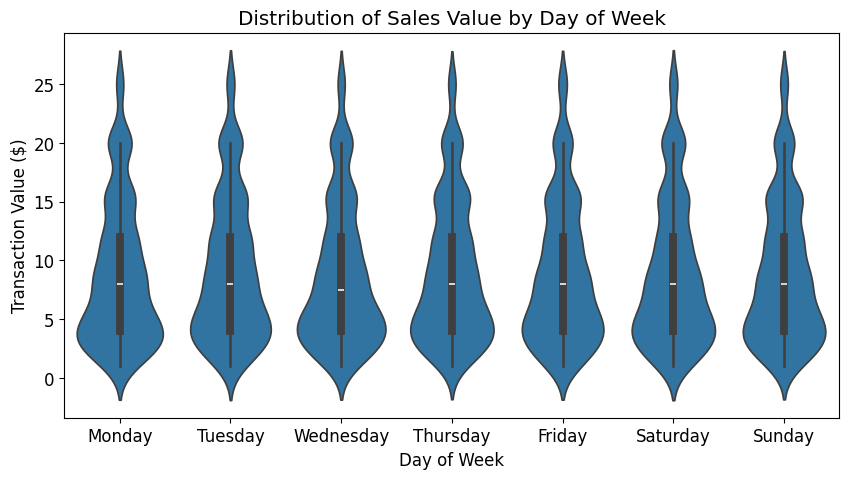

In [311]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(10, 5))
sns.violinplot(data=data, x='Day of Week', y='Total Spent', order=day_order)
plt.title('Distribution of Sales Value by Day of Week')
plt.ylabel('Transaction Value ($)')
plt.show()

Now I look at how the café physically operates. By analyzing where people eat and how they pay, I can uncover behavioral differences. For example, if 'Takeaway' customers favor Digital Wallets, it suggests an opportunity for a faster, tech-integrated checkout process for people on the go.

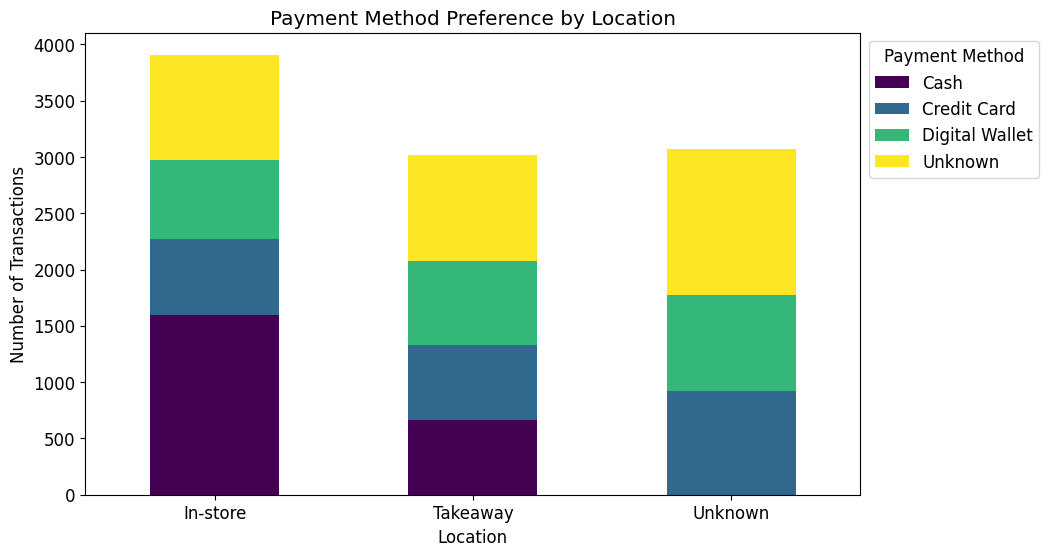

In [312]:
loc_pay = pd.crosstab(data['Location'], data['Payment Method'])

loc_pay.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Payment Method Preference by Location')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Payment Method', bbox_to_anchor=(1, 1))
plt.show()

Finally, I zoom in on product-specific behavior. Some items might be 'Takeaway Staples,' while others are 'In-store Experiences.' This can be useful for inventory management and deciding whether to invest more in premium packaging or better table service. One import thing to notice is that there are still 3000 rows with Unkown Location, so it can limit the strength of the conclusions.  

3069


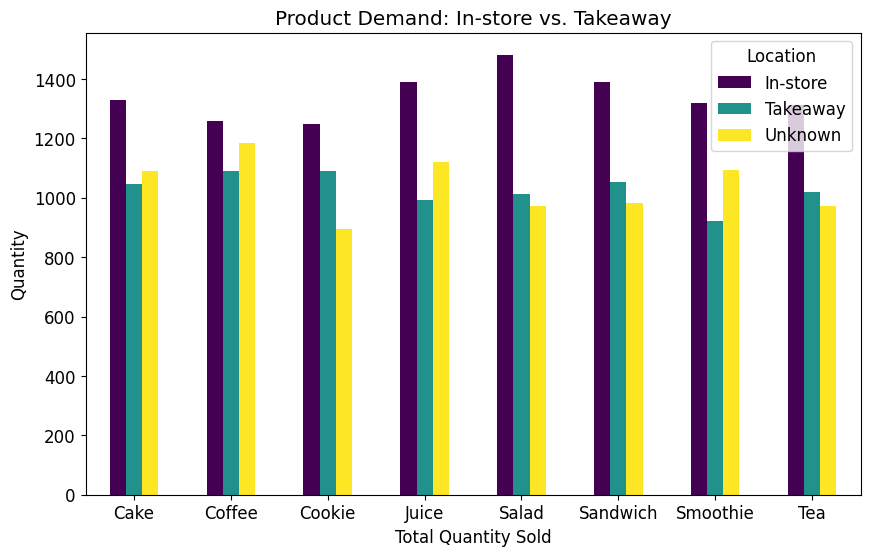

In [313]:
item_loc = data[data['Item'] != 'Unknown'].groupby(['Item', 'Location'])['Quantity'].sum().unstack()
print((data['Location']=='Unknown').sum())
item_loc.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Product Demand: In-store vs. Takeaway')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Quantity')
plt.xticks(rotation=0)
plt.savefig("In-store vs. Takeway.jpg", dpi=300, bbox_inches="tight")
plt.show()

That's all my analysis! Hope you enjoyed it!